In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
#Load Dataset
train=pd.read_csv(('/kaggle/input/competitions/titanic/train.csv'))
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test=pd.read_csv(('/kaggle/input/competitions/titanic/test.csv'))
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
#Dataset Size
train.shape

(891, 12)

In [5]:
test.shape

(418, 11)

In [6]:
#First 5 Rows
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
#Column information
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [9]:
#Statistics
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [11]:
#Missing Values
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [13]:
#Missing Values percentage

missing=train.isnull().sum()
missing_percent=(missing/len(missing))*100
print(missing_percent.sort_values(ascending=False))

Cabin          5725.000000
Age            1475.000000
Embarked         16.666667
PassengerId       0.000000
Name              0.000000
Pclass            0.000000
Survived          0.000000
Sex               0.000000
Parch             0.000000
SibSp             0.000000
Fare              0.000000
Ticket            0.000000
dtype: float64


In [14]:
#Will Passenger Survived?

train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [15]:
#Survival Percentage
train['Survived'].value_counts(normalize=True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

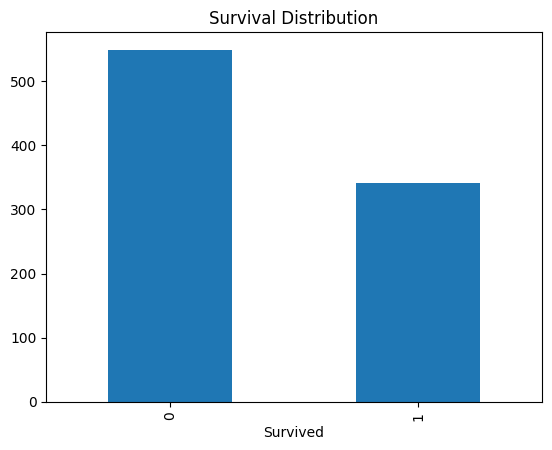

In [16]:
#Visualize Survival

train['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Distribution")
plt.show()

In [17]:
#Survival by Gender
train.groupby("Sex")["Survived"].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

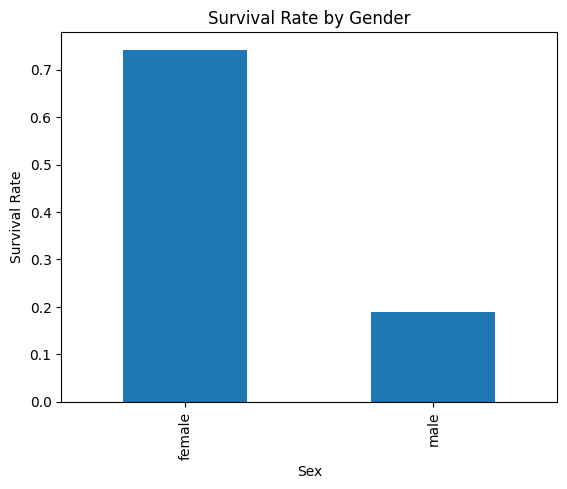

In [18]:
#Survival by gender visualization

train.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

In [19]:
#Survival by Passenger class
train.groupby("Pclass")["Survived"].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

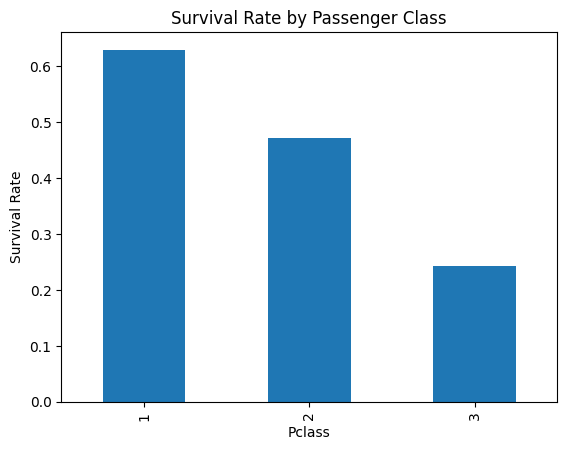

In [20]:
#Passenger class graph

train.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

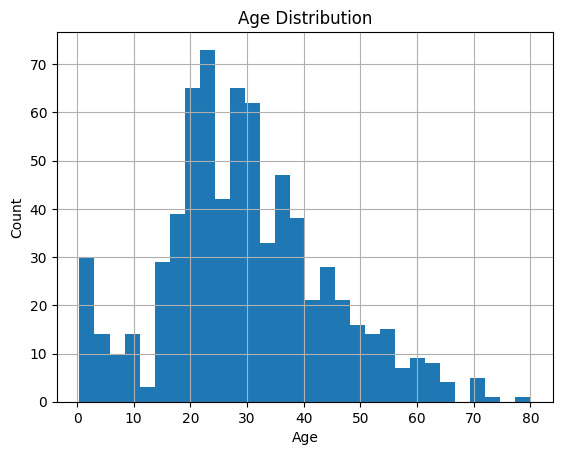

In [21]:
#Age distribution

train["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

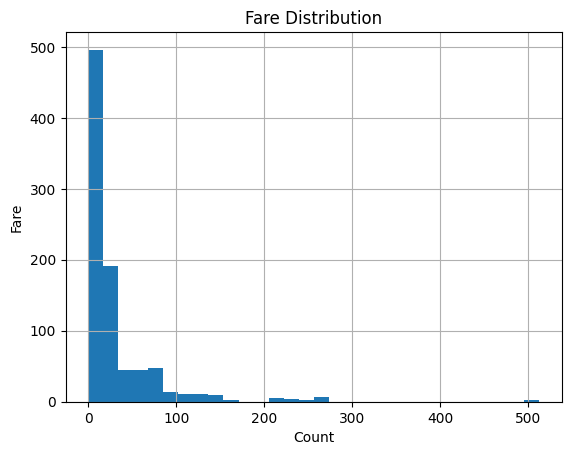

In [22]:
#Fare distribution

train["Fare"].hist(bins=30)
plt.title("Fare Distribution")
plt.ylabel("Fare")
plt.xlabel("Count")
plt.show()

In [23]:
#Survived by Embarked

train.groupby("Embarked")["Survived"].mean()*100

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64

In [24]:
#Family Size Feature

train["FamilySize"]=train["SibSp"]+train["Parch"]+1
train["FamilySize"].head()

0    2
1    2
2    1
3    2
4    1
Name: FamilySize, dtype: int64

In [25]:

test["FamilySize"]=test["SibSp"]+test["Parch"]+1
test["FamilySize"].head()

0    1
1    2
2    1
3    1
4    3
Name: FamilySize, dtype: int64

In [26]:
#Familysize survival

train.groupby("FamilySize")["Survived"].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [27]:
#Correlation Check

temp=train.copy()
temp["Sex"]=temp["Sex"].map({
    "male":0,
    "female":1
})
corr=temp[[
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "FamilySize"
]].corr()
print(corr["Survived"].sort_values(ascending=False))

Survived      1.000000
Sex           0.543351
Fare          0.257307
FamilySize    0.016639
Age          -0.077221
Pclass       -0.338481
Name: Survived, dtype: float64


In [28]:
#Checking missing values again

train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64

In [29]:
#Drop cabin column

train.drop("Cabin",axis=1,inplace=True)

In [30]:
test.drop("Cabin",axis=1,inplace=True)

In [31]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize'],
      dtype='object')

In [32]:
#Fill age missing Values

train["Age"]=train["Age"].fillna(train["Age"].median())

In [33]:
test["Age"]=train["Age"].fillna(train["Age"].median())

In [34]:
#Fill Embarked missing values

test["Age"]=test["Age"].fillna(test["Age"].median())
train["Embarked"]=train["Embarked"].fillna(
    train["Embarked"].mode()[0],
    )


In [35]:
#Fill fare missing values

test["Fare"]=test["Fare"].fillna(
    test["Fare"].median()
)

In [36]:
#Verifing whether the missing values removed or not

train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64

In [37]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64

In [38]:
#Create Isalone feature

train["IsAlone"]=(
    train["FamilySize"]==1
).astype(int)
test["IsAlone"]=(
    test["FamilySize"]==1
).astype(int)

In [39]:
train[["FamilySize","IsAlone"]].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [40]:
#Extract title from name

train["Title"]=train["Name"].str.extract(
    r"([A-Za-z]+)\.",
    expand=False
)
test["Title"]=test["Name"].str.extract(
    r"([A-Za-z]+)\.",
    expand=False
)

In [41]:
#Simplefy Rare titles

train["Title"]=train['Title'].replace(
    [
        "Lady","Countes","Capt",
        "Col","Don","Dr","Major",
        "Rev","Str","Jonkheer","Dona"
    ],
    "Rare"
)
test["Title"]=test['Title'].replace(
    [
        "Lady","Countess","Capt",
        "Col","Don","Dr","Major",
        "Rev","Sir","Jonkheer","Dona"
    ],
    "Rare"
)

In [42]:
#Convert Gender to number

train["Sex"]=train["Sex"].map({
    "male":0,
    "female":1
})
test["Sex"]=test["Sex"].map({
    "male":0,
    "female":1
})

In [43]:
#Convert Embarked to numbers

train["Embarked"]=train["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})
test["Embarked"]=test["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

In [44]:
#Convert title to numbers

title_mapping={
    "Mr":1,
    "Miss":2,
    "Mrs":3,
    "Master":4,
    "Rare":5
}
train["Tile"]=train["Title"].map(title_mapping)
test["Title"]=test["Title"].map(title_mapping)

In [45]:
#Fill remaining title to nulls

train["Title"]=train["Title"].fillna(0)

In [46]:
test["Title"]=test["Title"].fillna(0)

In [47]:
train["Title"].isnull().sum()

np.int64(0)

In [48]:
test["Title"].isnull().sum()

np.int64(0)

In [49]:
#Final features list

features=[
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]
print(features)

['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


In [50]:
#Create X and y

X=train[features]
y=train["Survived"]
X_test=test[features]

In [51]:
print(X.shape)

(891, 8)


In [52]:
print(y.shape)

(891,)


In [53]:
print(X_test.shape)

(418, 8)


In [54]:
X.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title
0,3,0,22.0,7.2500,0,2,0,Mr
1,1,1,38.0,71.2833,1,2,0,Mrs
2,3,1,26.0,7.9250,0,1,1,Miss
3,1,1,35.0,53.1000,0,2,0,Mrs
4,3,0,35.0,8.0500,0,1,1,Mr


In [55]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Sex         891 non-null    int64  
 2   Age         891 non-null    float64
 3   Fare        891 non-null    float64
 4   Embarked    891 non-null    int64  
 5   FamilySize  891 non-null    int64  
 6   IsAlone     891 non-null    int64  
 7   Title       891 non-null    object 
dtypes: float64(2), int64(5), object(1)
memory usage: 55.8+ KB


In [56]:
print(train.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'Tile']


In [57]:
for col in features:
    print(col,col in train.columns)

Pclass True
Sex True
Age True
Fare True
Embarked True
FamilySize True
IsAlone True
Title True


In [58]:
#Split Training Data

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_valid.shape)

(712, 8)
(179, 8)


In [59]:
X_train.select_dtypes(include=['object']).columns

Index(['Title'], dtype='object')

In [60]:
X_train = pd.get_dummies(X_train,drop_first=True)
X_test = pd.get_dummies(X_test,drop_first=True)
X_train,X_test = X_train.align(X_test, join='left',axis=1,fill_value=0)

In [61]:
X_train.isnull().sum()

Pclass          0
Sex             0
Age             0
Fare            0
Embarked        0
FamilySize      0
IsAlone         0
Title_Master    0
Title_Miss      0
Title_Mlle      0
Title_Mme       0
Title_Mr        0
Title_Mrs       0
Title_Ms        0
Title_Rare      0
dtype: int64

In [62]:
print(X_train.isnull().sum()[X_train.isnull().sum()>0])

Series([], dtype: int64)


In [63]:
print(X_train.columns.tolist())

['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rare']


In [64]:
print(X_valid.columns.tolist())

['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


In [65]:
print(X_train.dtypes)

Pclass            int64
Sex               int64
Age             float64
Fare            float64
Embarked          int64
FamilySize        int64
IsAlone           int64
Title_Master       bool
Title_Miss         bool
Title_Mlle         bool
Title_Mme          bool
Title_Mr           bool
Title_Mrs          bool
Title_Ms           bool
Title_Rare         bool
dtype: object


In [66]:
X_train=X_train.replace({True:1,False:0})
X_valid=X_valid.replace({True:1,False:0})

/tmp/ipykernel_16/3498637982.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train=X_train.replace({True:1,False:0})


In [67]:
print(X_train.dtypes)

Pclass            int64
Sex               int64
Age             float64
Fare            float64
Embarked          int64
FamilySize        int64
IsAlone           int64
Title_Master      int64
Title_Miss        int64
Title_Mlle        int64
Title_Mme         int64
Title_Mr          int64
Title_Mrs         int64
Title_Ms          int64
Title_Rare        int64
dtype: object


In [68]:
print(X_train.isnull().sum().sum())

0


In [69]:
print(X_valid.isnull().sum().sum())

0


In [70]:
print(X_train.columns.tolist())
print(X_valid.columns.tolist())
print(X_train.shape)
print(X_valid.shape)

['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rare']
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']
(712, 15)
(179, 8)


In [71]:
print(X_valid.head())

     Pclass  Sex   Age     Fare  Embarked  FamilySize  IsAlone   Title
709       3    0  28.0  15.2458         1           3        0  Master
439       2    0  31.0  10.5000         0           1        1      Mr
840       3    0  20.0   7.9250         0           1        1      Mr
720       2    1   6.0  33.0000         0           2        0    Miss
39        3    1  14.0  11.2417         1           2        0    Miss


In [72]:
X_valid=pd.get_dummies(X_valid,drop_first=True)

X_train,X_valid=X_train.align(
    X_valid,
    join='left',
    axis=1,fill_value=0
)
print(X_train.shape)
print(X_valid.shape)

(712, 15)
(179, 15)


In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
model = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)
model.fit(X_train,y_train)
preds=model.predict(X_valid)
print("Accuracy:",accuracy_score(y_valid,preds))

Accuracy: 0.8435754189944135


In [74]:
print(X_train.columns.tolist())
print(X_valid.columns.tolist())
print(X_train.dtypes)
print(X_valid.dtypes)
print(X_valid.head())

['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rare']
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rare']
Pclass            int64
Sex               int64
Age             float64
Fare            float64
Embarked          int64
FamilySize        int64
IsAlone           int64
Title_Master      int64
Title_Miss        int64
Title_Mlle        int64
Title_Mme         int64
Title_Mr          int64
Title_Mrs         int64
Title_Ms          int64
Title_Rare        int64
dtype: object
Pclass            int64
Sex               int64
Age             float64
Fare            float64
Embarked          int64
FamilySize        int64
IsAlone           int64
Title_Master      int64
Title_Miss         bool
Title_Mlle        int64
Title_Mme         int64
Title_

In [75]:
X_valid=pd.get_dummies(X_valid,drop_first=True)
X_train,X_valid = X_train.align(
    X_valid,
    join='left',
    axis=1,
    fill_value=0
)
print(X_train.shape)
print(X_valid.shape)
print(X_valid.columns.tolist())

(712, 15)
(179, 15)
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rare']


In [76]:
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=['number']).columns

num_imputer =SimpleImputer(strategy='median')

X_train[num_cols]=num_imputer.fit_transform(X_train[num_cols])
X_valid[num_cols]=num_imputer.transform(X_valid[num_cols])
#cat_cols=["Sex","Embarked"]
#print(cat_cols)

In [77]:
from sklearn.impute import SimpleImputer
train_cols=X_train.columns
imputer=SimpleImputer(strategy='median')
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=train_cols
    )
X_valid =pd.DataFrame(
    imputer.transform(X_valid),
    columns=train_cols
)

In [78]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [79]:
#Logistic Prediction

lr_pred = lr_model.predict(X_valid)

In [80]:
#Logistic Accuracy

from sklearn.metrics import accuracy_score
lr_accuracy = accuracy_score(
    y_valid,
    lr_pred
)
print("Logistic Accuracy:",lr_accuracy)

Logistic Accuracy: 0.7932960893854749


In [81]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(
    y_valid,
    lr_pred
)
print(cm)

[[89 16]
 [21 53]]


In [82]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
rf_model= RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [83]:
#Random Forest Accuracy

rf_pred = rf_model.predict(X_valid)
rf_accuracy = accuracy_score(
    y_valid,
    rf_pred
)
print("Random Forest Accuracy",rf_accuracy)

Random Forest Accuracy 0.8212290502793296


In [84]:
#Compare Models

print("Logistic Regression:",lr_accuracy)

Logistic Regression: 0.7932960893854749


In [85]:
print("Random Forest:",rf_accuracy)

Random Forest: 0.8212290502793296


In [86]:
#Feature Importance

print(len(features))
print(len(rf_model.feature_importances_))
features=X.columns
print(features)

8
15
Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone',
       'Title'],
      dtype='object')


In [87]:
X_encoded=pd.get_dummies(X)
rf_model.fit(X_encoded,y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [88]:
features = X_encoded.columns
importance =pd.DataFrame({
    "Feature":features,
    "Importance":rf_model.feature_importances_
})
importance=importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

           Feature  Importance
3             Fare    0.248757
2              Age    0.223529
12        Title_Mr    0.138891
1              Sex    0.118619
0           Pclass    0.084171
5       FamilySize    0.067220
4         Embarked    0.029843
9       Title_Miss    0.029725
13       Title_Mrs    0.026731
6          IsAlone    0.012117
8     Title_Master    0.009930
15      Title_Rare    0.009156
16       Title_Sir    0.000710
14        Title_Ms    0.000217
10      Title_Mlle    0.000202
11       Title_Mme    0.000096
7   Title_Countess    0.000088


In [89]:
print(X.dtypes)

Pclass          int64
Sex             int64
Age           float64
Fare          float64
Embarked        int64
FamilySize      int64
IsAlone         int64
Title          object
dtype: object


In [90]:
X_encoded = pd.get_dummies(X,columns=['Title'])

final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
final_model.fit(X_encoded,y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [91]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
X['Title'] = le.fit_transform(X['Title'])

final_model=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
final_model.fit(X,y)

/tmp/ipykernel_16/3913739638.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Title'] = le.fit_transform(X['Title'])


RandomForestClassifier(n_estimators=200, random_state=42)

In [92]:
print(X.columns)

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone',
       'Title'],
      dtype='object')


In [93]:
print(X.head())
print(X.columns)
final_model.fit(X_encoded,y)
print(X.columns)
print(X.head())

   Pclass  Sex   Age     Fare  Embarked  FamilySize  IsAlone  Title
0       3    0  22.0   7.2500         0           2        0      5
1       1    1  38.0  71.2833         1           2        0      6
2       3    1  26.0   7.9250         0           1        1      2
3       1    1  35.0  53.1000         0           2        0      6
4       3    0  35.0   8.0500         0           1        1      5
Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone',
       'Title'],
      dtype='object')
Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone',
       'Title'],
      dtype='object')
   Pclass  Sex   Age     Fare  Embarked  FamilySize  IsAlone  Title
0       3    0  22.0   7.2500         0           2        0      5
1       1    1  38.0  71.2833         1           2        0      6
2       3    1  26.0   7.9250         0           1        1      2
3       1    1  35.0  53.1000         0           2        0      6
4       3    0  35.0  

In [94]:
#Train final model on full dataset

final_model= RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
final_model.fit(X,y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [95]:
X_test=X_test.reindex(columns=X_train.columns,fill_value=0)

In [96]:
X_test=pd.get_dummies(X_test)
X_test=X_test.reindex(columns=X_train.columns,fill_value=0)
final_model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [97]:
test_features=test.copy()

#FamilySize and IsAlone create
test_features["FamilySize"]=test_features["SibSp"]+test_features["Parch"]+1
test_features["IsAlone"]=0
test_features.loc[test_features["FamilySize"]==1,"IsAlone"]=1

#Missing values fill
test_features["Age"]=test_features["Age"].fillna(test_features["Age"].median())
test_features["Fare"]=test_features["Fare"].fillna(test_features["Fare"].median())
test_features["Embarked"]=test_features["Embarked"].fillna(test_features["Embarked"].mode()[0])

#Title create from Name
test_features["Title"]=test_features["Name"].str.extract(
    r"([A-Za-z]+)\.",expand=False
)

#Same title cleaning used for training data
test_features["Title"]=test_features["Title"].replace(
    ["Lady","Countries","Capt","Col","Don","Dr","Major",
    "Rev","Sir","Jonkheer","Dona"],
    "Rare"
)

test_features["Title"]=test_features["Title"].replace({
    "MIle":"Miss",
    "Ms":"Miss",
    "Mme":"Mrs"
})

#Encode categorical columns
test_features["Sex"]=test_features["Sex"].map({"male":0,"female":1})

test_features["Embarked"]=test_features["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

#Same LableEncoder already fitted using X["Title"]
test_features["Title"]=le.transform(test_features["Title"])

#Keep ONLY same columns and same order as model training data
test_features= test_features[X.columns]

test_features.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title
0,3,NaN,22.0,7.8292,NaN,1,1,5
1,3,NaN,38.0,7.0000,NaN,2,0,6
2,2,NaN,26.0,9.6875,NaN,1,1,5
3,3,NaN,35.0,8.6625,NaN,1,1,5
4,3,NaN,35.0,12.2875,NaN,3,0,6


In [98]:
test_features["Sex"]=test["Sex"].map({"male":0,"female":1})
test_features["Embarked"]=test["Embarked"].map({"S":0,"C":1,"Q":2})
test_features["Embarked"]=test_features["Embarked"].fillna(0)
test_features.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title
0,3,NaN,22.0,7.8292,0.0,1,1,5
1,3,NaN,38.0,7.0000,0.0,2,0,6
2,2,NaN,26.0,9.6875,0.0,1,1,5
3,3,NaN,35.0,8.6625,0.0,1,1,5
4,3,NaN,35.0,12.2875,0.0,3,0,6


In [99]:
#Cross Validation

from sklearn.model_selection import cross_val_score
scores=cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)
print(scores)
print("Average Score:",scores.mean())

[0.78212291 0.79775281 0.85393258 0.76404494 0.81460674]
Average Score: 0.8024919967359236


In [100]:
#Better Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model2=RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)
rf_model2.fit(X_train,y_train)

pred2=rf_model2.predict(X_valid)
print(accuracy_score(y_valid,pred2))

0.8100558659217877


In [101]:
#Features importance Graph

importance=pd.DataFrame({
    "Feature":features,
    "Importance":rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

           Feature  Importance
3             Fare    0.248757
2              Age    0.223529
12        Title_Mr    0.138891
1              Sex    0.118619
0           Pclass    0.084171
5       FamilySize    0.067220
4         Embarked    0.029843
9       Title_Miss    0.029725
13       Title_Mrs    0.026731
6          IsAlone    0.012117
8     Title_Master    0.009930
15      Title_Rare    0.009156
16       Title_Sir    0.000710
14        Title_Ms    0.000217
10      Title_Mlle    0.000202
11       Title_Mme    0.000096
7   Title_Countess    0.000088


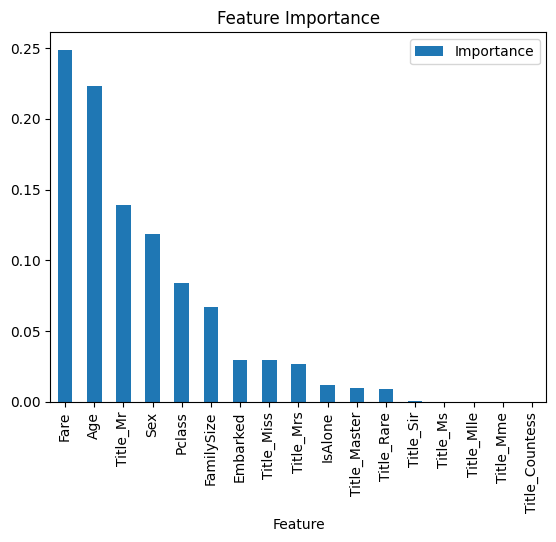

In [102]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)
plt.title("Feature Importance")
plt.show()

In [103]:
#Predict competition test data

final_predictions=final_model.predict(
    X_test
)

In [104]:
#Create submission file

submission=pd.DataFrame({
    "PassengerId":test["PassengerId"],
    "Survived":final_predictions
})
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [105]:
submission.to_csv("submission.csv",index=False)
print("File created successfully")

File created successfully


In [106]:
import os
print(os.listdir())

['__notebook__.ipynb', 'submission.csv']
